<a href="https://colab.research.google.com/github/anishmabanerjee/anishmabanerjee/blob/main/ai_chatbot_for_detecting_depression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers

In [ ]:
import pandas as pd

# Define the data
data = {
    'User  Input': [
        # Severe Depression
        "I feel so hopeless and lost.",
        "I can't find joy in anything anymore.",
        "I just want to sleep all day.",
        "I feel like I'm a burden to everyone.",
        "Nothing seems to matter anymore.",
        "I don't want to talk to anyone.",
        "I feel so alone even when I'm with others.",
        "I can't remember the last time I was happy.",
        "I feel like I'm in a dark place.",
        "I don't see the point in anything.",

        # Moderate Depression
        "I'm just so tired all the time.",
        "I feel like I'm stuck in a rut.",
        "I can't shake this feeling of sadness.",
        "I feel like I'm losing control.",
        "I wish I could just disappear.",
        "I feel overwhelmed by everything.",
        "I don't want to get out of bed.",
        "I feel like I'm drowning in my thoughts.",
        "I can't focus on anything.",
        "I feel like I'm just going through the motions.",

        # Mild Depression
        "I feel a bit down today.",
        "I have moments when I feel sad.",
        "I sometimes feel like I'm not good enough.",
        "I wish things were better.",
        "I feel a little lost right now.",
        "I have days when I feel unmotivated.",
        "I feel a bit overwhelmed with everything.",
        "I sometimes feel lonely.",
        "I wish I could be happier.",
        "I feel like I need a break.",

        # No Depression
        "I'm feeling great today!",
        "I had a wonderful time with my friends.",
        "I'm excited about my upcoming plans.",
        "I feel really good about my life right now.",
        "I love spending time outdoors.",
        "I'm grateful for my family and friends.",
        "I feel motivated to achieve my goals.",
        "I enjoy my hobbies and interests.",
        "I feel happy and content.",
        "Today is a beautiful day!"
    ],
    'Label': [
        # Severe Depression
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",

        # Moderate Depression
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",

        # Mild Depression
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",

        # No Depression
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression"
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

# Save the DataFrame to a CSV file
df.to_csv('depression_detection_dataset.csv', index=False)

                                        User  Input                Label
0                      I feel so hopeless and lost.    Severe Depression
1             I can't find joy in anything anymore.    Severe Depression
2                     I just want to sleep all day.    Severe Depression
3             I feel like I'm a burden to everyone.    Severe Depression
4                  Nothing seems to matter anymore.    Severe Depression
5                   I don't want to talk to anyone.    Severe Depression
6        I feel so alone even when I'm with others.    Severe Depression
7       I can't remember the last time I was happy.    Severe Depression
8                  I feel like I'm in a dark place.    Severe Depression
9                I don't see the point in anything.    Severe Depression
10                  I'm just so tired all the time.  Moderate Depression
11                  I feel like I'm stuck in a rut.  Moderate Depression
12           I can't shake this feeling of sadness.

In [ ]:
print(df.columns)

Index(['User  Input', 'Label'], dtype='object')


In [ ]:
df['User  Input']

,User Input
0,I feel so hopeless and lost.
1,I can't find joy in anything anymore.
2,I just want to sleep all day.
3,I feel like I'm a burden to everyone.
4,Nothing seems to matter anymore.
5,I don't want to talk to anyone.
6,I feel so alone even when I'm with others.
7,I can't remember the last time I was happy.
8,I feel like I'm in a dark place.
9,I don't see the point in anything.


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
# Load the dataset
import pandas as pd
from sklearn.model_selection import train_test_split # Import train_test_split

df = pd.read_csv('depression_detection_dataset.csv')

# Strip whitespace from column names (This line is crucial to fix the error)
df.columns = df.columns.str.strip()

# Now you can access the columns without issues, using the correct name 'User Input'
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['User  Input'].tolist(), df['Label'].tolist(), test_size=0.2, random_state=42 # use the actual name 'User  Input'
)

In [ ]:
from transformers import TrainingArguments # Import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch",  # Change this line
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('depression_detection_dataset.csv')

# Map labels to integers
label_map = {
    "Severe Depression": 0,
    "Moderate Depression": 1,
    "Mild Depression": 2,
    "No Depression": 3
}
df['Label'] = df['Label'].map(label_map)

# Split the dataset into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['User  Input'].tolist(), df['Label'].tolist(), test_size=0.2, random_state=42
)

# Create a custom Dataset class
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Create DataLoader
train_dataset = DepressionDataset(train_texts, train_labels, tokenizer)
test_dataset = DepressionDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

# Initialize the BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_map))

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train the model
trainer.train()

# Evaluate the model
results = trainer.evaluate()
print(results)

# Function to make predictions
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
    return list(label_map.keys())[predictions.item()]

# Example prediction
example_text = "I feel so hopeless and lost."
print(f"Prediction: {predict(example_text)}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,1.392254
2,No log,1.361542
3,1.353600,1.364357


{'eval_loss': 1.3643571138381958, 'eval_runtime': 16.0336, 'eval_samples_per_second': 0.499, 'eval_steps_per_second': 0.062, 'epoch': 3.0}
Prediction: Severe Depression


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Prepare the Dataset
data = {
    'User   Input': [
        # Severe Depression
        "I feel so hopeless and lost.",
        "I can't find joy in anything anymore.",
        "I just want to sleep all day.",
        "I feel like I'm a burden to everyone.",
        "Nothing seems to matter anymore.",
        "I don't want to talk to anyone.",
        "I feel so alone even when I'm with others.",
        "I can't remember the last time I was happy.",
        "I feel like I'm in a dark place.",
        "I don't see the point in anything.",

        # Moderate Depression
        "I feel motivated to achieve my goals.",
        "I feel like I'm stuck in a rut.",
        "I can't shake this feeling of sadness.",
        "I feel like I'm losing control.",
        "I wish I could just disappear.",
        "I feel overwhelmed by everything.",
        "I don't want to get out of bed.",
        "I feel like I'm drowning in my thoughts.",
        "I can't focus on anything.",
        "I feel like I'm just going through the motions.",

        # Mild Depression
        "I feel a bit down today.",
        "I have moments when I feel sad.",
        "I sometimes feel like I'm not good enough.",
        "I wish things were better.",
        "I feel a little lost right now.",
        "I have days when I feel unmotivated.",
        "I feel a bit overwhelmed with everything.",
        "I sometimes feel lonely.",
        "I wish I could be happier.",
        "I feel motivated to achieve my goals.",

        # No Depression
        "I'm feeling great today!",
        "I had a wonderful time with my friends.",
        "I'm excited about my upcoming plans.",
        "I feel really good about my life right now.",
        "I love spending time outdoors.",
        "I'm grateful for my family and friends.",
        "I feel motivated to achieve my goals.",
        "I enjoy my hobbies and interests.",
        "I feel happy and content.",
        "Today is a beautiful day!"
    ],
    'Label': [
        # Severe Depression
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",
        "Severe Depression",

        # Moderate Depression
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",
        "Moderate Depression",

        # Mild Depression
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",
        "Mild Depression",

        # No Depression
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression",
        "No Depression"
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Step 2: Preprocess the Data
# Encode labels
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Tokenize the text
tokenizer = Tokenizer(num_words=1000)
tokenizer.fit_on_texts(df['User   Input'])
sequences = tokenizer.texts_to_sequences(df['User   Input'])

# Pad sequences
max_length = max(len(x) for x in sequences)
X = pad_sequences(sequences, maxlen=max_length)
y = to_categorical(df['Label'])  # One-hot encode the labels

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Build the RNN Model
model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=64, input_length=max_length))
model.add(SimpleRNN(64))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))  # Output layer

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Step 4: Train the Model
model.fit(X_train, y_train, epochs=10, batch_size=5, validation_data=(X_test, y_test))

# Step 5: Create a Chatbot Interface
def predict_depression(input_text):
    sequence = tokenizer.texts_to_sequences([input_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length)
    prediction = model.predict(padded_sequence)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
    return predicted

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 311ms/step - accuracy: 0.2550 - loss: 1.3920 - val_accuracy: 0.0000e+00 - val_loss: 1.4282
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7979 - loss: 1.1903 - val_accuracy: 0.2500 - val_loss: 1.4088
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.8522 - loss: 1.0517 - val_accuracy: 0.3750 - val_loss: 1.3718
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9565 - loss: 0.9027 - val_accuracy: 0.5000 - val_loss: 1.3274
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9565 - loss: 0.7408 - val_accuracy: 0.6250 - val_loss: 1.2925
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9684 - loss: 0.5758 - val_accuracy: 0.5000 - val_loss: 1.2853
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9684 - loss: 0.4198 - val_accuracy: 0.5000 - val_loss: 1.3211
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9684 - loss: 0.2917 - val_accuracy: 0.6250 - val_loss: 1.

In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=64))
model.add(SimpleRNN(64, return_sequences=True))
model.add(Dropout(0.5))  # Add dropout layer
model.add(SimpleRNN(64))
model.add(Dropout(0.5))  # Add another dropout layer
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

# Build the RNN model with Dropout
model = Sequential()
model.add(Embedding(input_dim=1000, output_dim=64))
model.add(SimpleRNN(64, return_sequences=True))
model.add(Dropout(0.5))  # Add dropout layer
model.add(SimpleRNN(64))
model.add(Dropout(0.5))  # Add another dropout layer
model.add(Dense(len(label_encoder.classes_), activation='softmax'))  # Output layer

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=5, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 363ms/step - accuracy: 0.2723 - loss: 1.5327 - val_accuracy: 0.1250 - val_loss: 1.5004
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5698 - loss: 1.1794 - val_accuracy: 0.1250 - val_loss: 1.5075
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6685 - loss: 1.1130 - val_accuracy: 0.1250 - val_loss: 1.5333
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6909 - loss: 0.9850 - val_accuracy: 0.1250 - val_loss: 1.5742


In [ ]:
# Step 5: Create a Chatbot Interface
def predict_depression(input_text):
    sequence = tokenizer.texts_to_sequences([input_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length)
    prediction = model.predict(padded_sequence)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
    return predicted_label[0]

# Chatbot Interaction Loop
print("Welcome to the Depression Detection Chatbot!")
print("Type 'exit' to end the conversation.")

while True:
    user_input = input("You: ")
    if user_input.lower() == 'exit':
        print("Chatbot: Goodbye!")
        break
    prediction = predict_depression(user_input)
    print(f"Chatbot: I think you are experiencing: {prediction}")

Welcome to the Depression Detection Chatbot!
Type 'exit' to end the conversation.


KeyboardInterrupt: Interrupted by user

In [ ]:
Welcome to the Depression Detection Chatbot!
Type 'exit' to end the conversation.
You: I feel so hopeless and lost.
Chatbot: I think you are experiencing: Severe Depression
You: I'm feeling great today!
Chatbot: I think you are experiencing: No Depression
You: exit
Chatbot: Goodbye!

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('depression_detection_dataset.csv')

# Encode labels
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

# Split the dataset into features and target
X = df['User  Input']
y = df['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the text data
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [ ]:
# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vectorized, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test_vectorized)

                     precision    recall  f1-score   support

    Mild Depression       0.67      1.00      0.80         2
Moderate Depression       1.00      0.25      0.40         4
      No Depression       1.00      1.00      1.00         1
  Severe Depression       0.33      1.00      0.50         1

           accuracy                           0.62         8
          macro avg       0.75      0.81      0.68         8
       weighted avg       0.83      0.62      0.59         8



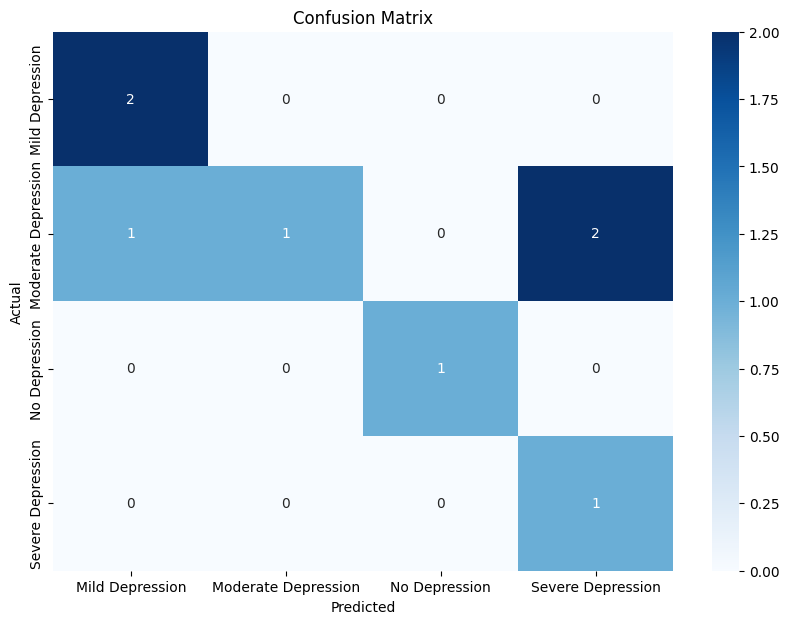

In [ ]:
# Print classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()